In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Global plot style

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 120

# BASIC DATA UNDERSTANDING

In [45]:
df = pd.read_csv('main_Bikewale.csv')

In [46]:
print(df.shape)

(418, 6)


In [47]:
print(df.dtypes)

Model Name               str
Engine Size              str
Mileage                  str
Average Rating       float64
Number of Ratings    float64
Price                    str
dtype: object


In [48]:
df.head()

,Model Name,Engine Size,Mileage,Average Rating,Number of Ratings,Price
0,KTM 200 Duke,199.5 cc,35 kmpl,4.7,621.0,"1,91,570"
1,Bajaj Pulsar N250,249 cc,44 kmpl,4.6,398.0,"1,38,823"
2,Honda CB350RS,348.36 cc,35 kmpl,4.6,223.0,"1,97,914"
3,TVS Apache RTR 160 4V,159.7 cc,41.4 kmpl,4.5,2306.0,"1,16,491"
4,Yezdi Roadster,334 cc,30 kmpl,4.6,182.0,"1,98,916"


In [49]:
df.tail()

,Model Name,Engine Size,Mileage,Average Rating,Number of Ratings,Price
413,Indian 101 Scout,1250 cc,NaN,NaN,NaN,"17,08,855"
414,Indian Super Scout,1250 cc,NaN,NaN,NaN,"17,25,954"
415,Kawasaki Versys 1100,1099 cc,NaN,NaN,NaN,"13,89,000"
416,Numeros n-First,3 kWh,NaN,NaN,NaN,"77,943"
417,Ducati Desmo450 MX,449.6 cc,NaN,NaN,NaN,"17,23,600"


In [50]:
df.describe(include='all')

,Model Name,Engine Size,Mileage,Average Rating,Number of Ratings,Price
count,418,418,354,317.000000,379.000000,418
unique,418,181,150,NaN,NaN,406
top,KTM 200 Duke,3 kWh,35 kmpl,NaN,NaN,"89,999"
freq,1,12,14,NaN,NaN,3
mean,NaN,NaN,NaN,4.346057,192.963061,NaN
std,NaN,NaN,NaN,0.543219,497.807552,NaN
min,NaN,NaN,NaN,1.700000,1.000000,NaN
25%,NaN,NaN,NaN,4.300000,6.000000,NaN
50%,NaN,NaN,NaN,4.500000,24.000000,NaN
75%,NaN,NaN,NaN,4.700000,149.000000,NaN


In [51]:
df.isnull().sum()

Model Name             0
Engine Size            0
Mileage               64
Average Rating       101
Number of Ratings     39
Price                  0
dtype: int64

# DATA CLEANING

### Identifying Bike Type (Petrol vs Electric)

In [ ]:
## Creates Bike_Type column — 'Electric' if engine has 'kWh', else 'Petrol'

df['Bike_Type'] = df['Engine Size'].apply(lambda x: 'Electric' if 'kWh' in str(x) else 'Petrol')

In [53]:
## Bike Type Distribution
print(df['Bike_Type'].value_counts())

Bike_Type
Petrol      314
Electric    104
Name: count, dtype: int64


### Parse Engine Size (cc for petrol , kWh for EV)

In [ ]:
## Extracts numeric engine value from strings → Engine_val (float)

df['Engine_val'] = df['Engine Size'].str.extract(r'([\d.]+)').astype(float)

### Parse Mileage — IMPORTANT: two different units exist


In [ ]:
## Splits Mileage into Mileage_val (number) + Mileage_unit (kmpl/km)

df['Mileage_val']  = df['Mileage'].str.extract(r'([\d.]+)').astype(float)
df['Mileage_unit'] = df['Mileage'].str.extract(r'([a-zA-Z/]+$)').iloc[:, 0]

In [ ]:
# Engine_val → fill with median within each Bike_Type
df['Engine_val'] = df.groupby('Bike_Type')['Engine_val'] \
                     .transform(lambda x: x.fillna(x.median()))

# Mileage_unit → fill with the most common unit per Bike_Type
# (Petrol → 'kmpl', Electric → 'km' in most datasets)
df['Mileage_unit'] = df.groupby('Bike_Type')['Mileage_unit'] \
                       .transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else 'kmpl'))

In [57]:
# Mileage Unit Distribution

print(df['Mileage_unit'].value_counts())

Mileage_unit
kmpl    314
km      104
Name: count, dtype: int64


In [58]:
# Drop raw 'Mileage' column — already parsed into Mileage_val (numeric) and Mileage_unit
# Keeping it would cause confusion between the messy string and the clean derived columns
df.drop(columns=['Mileage'], inplace=True)

### Clean Price  (remove commas → float, values in ₹)

In [ ]:
## Removes commas from Price → converts to float; prints ₹47K–₹1Cr range

df['Price'] = df['Price'].str.replace(',', '').astype(float)
 
print("\nPrice range: ₹{:,.0f}  to  ₹{:,.0f}".format(df['Price'].min(), df['Price'].max()))


Price range: ₹47,686  to  ₹10,000,000


### Create clean sub-DataFrames for analysis

In [ ]:
# Petrol bikes with fuel efficiency in kmpl (comparable)
petrol_kmpl = df[(df['Bike_Type'] == 'Petrol') & (df['Mileage_unit'] == 'kmpl')].copy()

In [ ]:
# Petrol bikes with range in km
petrol_km   = df[(df['Bike_Type'] == 'Petrol') & (df['Mileage_unit'] == 'km')].copy()

In [62]:
# All petrol bikes
petrol = df[df['Bike_Type'] == 'Petrol'].copy()

In [63]:
# Electric bikes
electric = df[df['Bike_Type'] == 'Electric'].copy()


### MISSING VALUE ANALYSIS

In [64]:
print(df.isnull().sum())

Model Name             0
Engine Size            0
Average Rating       101
Number of Ratings     39
Price                  0
Bike_Type              0
Engine_val             0
Mileage_val           64
Mileage_unit           0
dtype: int64


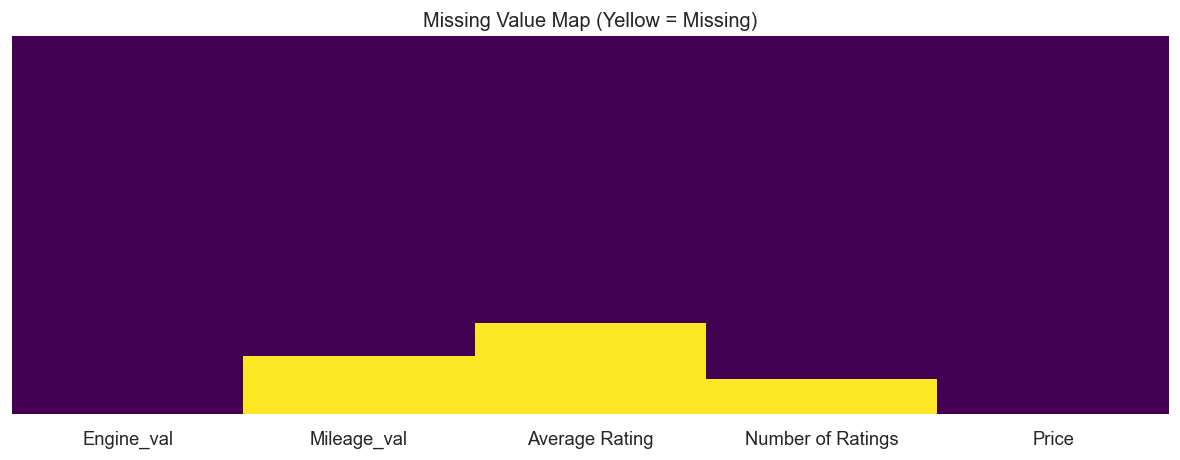

In [65]:
# Visualise missing values
plt.figure(figsize=(10, 4))
sns.heatmap(df[['Engine_val', 'Mileage_val', 'Average Rating',
                'Number of Ratings', 'Price']].isnull(),
            cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing Value Map (Yellow = Missing)')
plt.tight_layout()
plt.savefig('missing_heatmap.png')
plt.show()

### HANDLE MISSING VALUES

In [66]:
# Average Rating → fill with median (ratings are skewed toward 4-5)
df['Average Rating'] = df['Average Rating'].fillna(df['Average Rating'].median())

In [67]:
# Number of Ratings → NaN means no reviews yet → fill with 0
df['Number of Ratings'] = df['Number of Ratings'].fillna(0)

In [68]:
# Mileage → fill with median WITHIN each bike type + unit group
# (petrol kmpl median ≠ EV km range median)
df['Mileage_val'] = df.groupby(['Bike_Type', 'Mileage_unit'])['Mileage_val'] \
                      .transform(lambda x: x.fillna(x.median()))

## Fallback for rows where Mileage was fully blank (unit also NaN)
# Fill using median of their Bike_Type regardless of unit
df['Mileage_val'] = df.groupby('Bike_Type')['Mileage_val'] \
                      .transform(lambda x: x.fillna(x.median()))

In [69]:
# Recreate sub-DataFrames after filling
petrol       = df[df['Bike_Type'] == 'Petrol'].copy()
petrol_kmpl  = df[(df['Bike_Type'] == 'Petrol') & (df['Mileage_unit'] == 'kmpl')].copy()
electric     = df[df['Bike_Type'] == 'Electric'].copy()

In [ ]:
## Defines engine_segment() → classifies bikes as Commuter/Mid/Premium/SuperBike

def engine_segment(cc):
    if cc < 125:   return 'Commuter (<125cc)'
    elif cc < 300: return 'Mid-Range (125–300cc)'
    elif cc < 600: return 'Premium (300–600cc)'
    else:          return 'Super Bike (600cc+)'

In [71]:
petrol['Engine_Segment']      = petrol['Engine_val'].apply(engine_segment)
petrol_kmpl['Engine_Segment'] = petrol_kmpl['Engine_val'].apply(engine_segment)

In [ ]:
## Missing values after cleaning

print(df[['Engine_val', 'Mileage_val', 'Average Rating','Number of Ratings', 'Price']].isnull().sum())

Engine_val           0
Mileage_val          0
Average Rating       0
Number of Ratings    0
Price                0
dtype: int64


### FEATURE ENGINEERING

In [73]:
# -- Engine Segment (petrol only, based on cc) --

def engine_segment(cc):
    if cc < 125:   return 'Commuter (<125cc)'
    elif cc < 300: return 'Mid-Range (125–300cc)'
    elif cc < 600: return 'Premium (300–600cc)'
    else:          return 'Super Bike (600cc+)'

In [74]:
petrol['Engine_Segment'] = petrol['Engine_val'].apply(engine_segment)
print("\nPetrol Engine Segments:")
print(petrol['Engine_Segment'].value_counts())


Petrol Engine Segments:
Engine_Segment
Super Bike (600cc+)      122
Mid-Range (125–300cc)     76
Premium (300–600cc)       67
Commuter (<125cc)         49
Name: count, dtype: int64


In [75]:
# -- Price Category (all bikes) --
def price_category(price):
    if price < 100_000:   return 'Budget (<₹1L)'
    elif price < 300_000: return 'Mid-Range (₹1–3L)'
    elif price < 1_000_000: return 'Premium (₹3–10L)'
    else:                 return 'Luxury (₹10L+)'

In [76]:
df['Price_Category']     = df['Price'].apply(price_category)
petrol['Price_Category'] = petrol['Price'].apply(price_category)
print("\nPrice Categories (all bikes):")
print(df['Price_Category'].value_counts())


Price Categories (all bikes):
Price_Category
Mid-Range (₹1–3L)    162
Luxury (₹10L+)       102
Budget (<₹1L)         88
Premium (₹3–10L)      66
Name: count, dtype: int64


### OUTLIER DETECTION

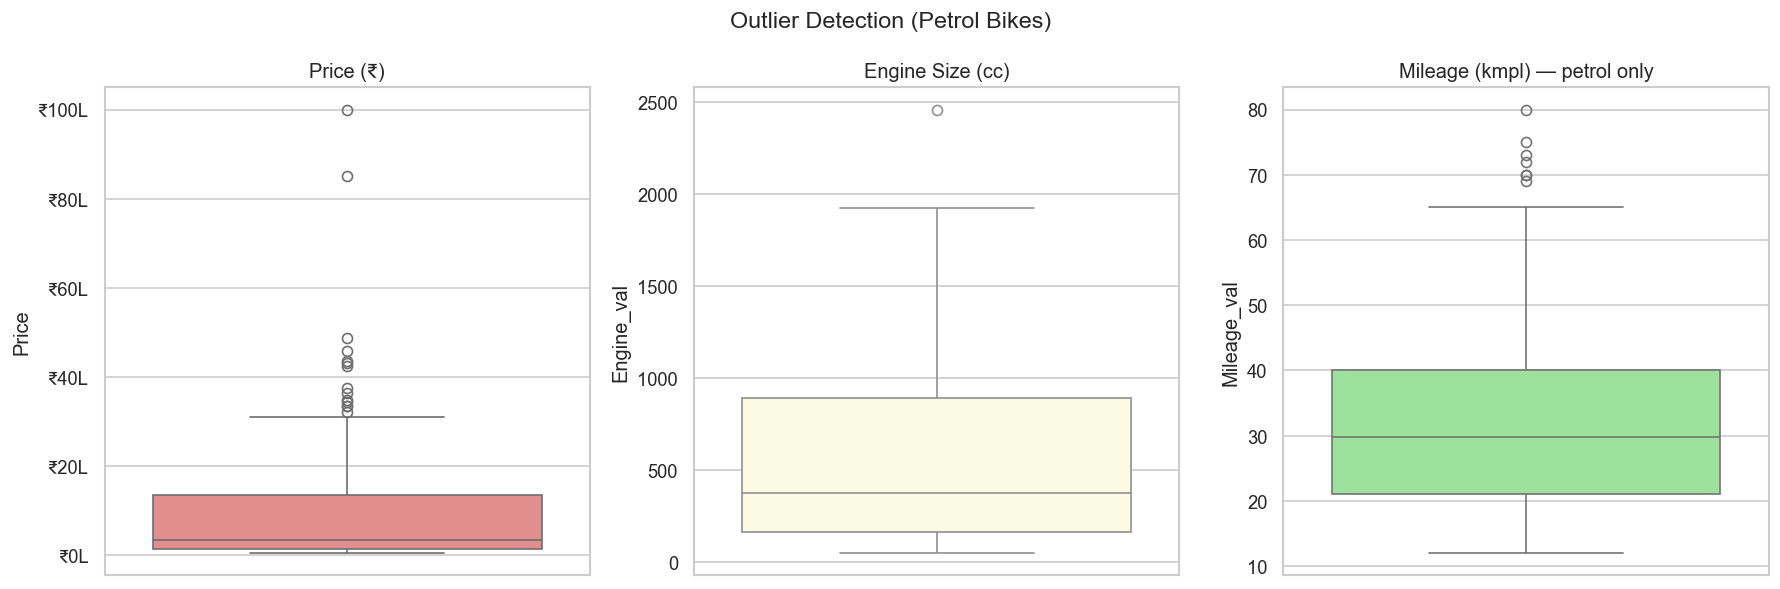

In [ ]:
## Box plots to visualize outliers across numeric columns

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Outlier Detection (Petrol Bikes)', fontsize=14)
 
sns.boxplot(y=petrol['Price'], ax=axes[0], color='lightcoral')
axes[0].set_title('Price (₹)')
axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'₹{x/1_00_000:.0f}L')
)
 
sns.boxplot(y=petrol['Engine_val'], ax=axes[1], color='lightyellow')
axes[1].set_title('Engine Size (cc)')

# For mileage, only use kmpl bikes to avoid mixing units
sns.boxplot(y=petrol_kmpl['Mileage_val'], ax=axes[2], color='lightgreen')
axes[2].set_title('Mileage (kmpl) — petrol only')
 
plt.tight_layout()
plt.savefig('outlier_boxplots.png')
plt.show()

In [78]:
# Summary of key outliers
print("\nTop 5 Expensive Petrol Bikes:")
print(petrol.nlargest(5, 'Price')[['Model Name', 'Price']].to_string(index=False))
 
print("\nTop 5 Highest cc Petrol Bikes:")
print(petrol.nlargest(5, 'Engine_val')[['Model Name', 'Engine_val']].to_string(index=False))


Top 5 Expensive Petrol Bikes:
                    Model Name      Price
Ducati Panigale V4 Lamborghini 10000000.0
          Ducati Panigale V4 R  8499000.0
                 BMW M 1000 XR  4863000.0
    Harley-Davidson Road Glide  4575000.0
      Ducati Multistrada V4 RS  4346700.0

Top 5 Highest cc Petrol Bikes:
                  Model Name  Engine_val
            Triumph Rocket 3      2458.0
    Harley-Davidson Breakout      1923.0
  Harley-Davidson Street Bob      1923.0
  Harley-Davidson Road Glide      1923.0
Harley-Davidson Street Glide      1923.0


In [79]:
df.head()

,Model Name,Engine Size,Average Rating,Number of Ratings,Price,Bike_Type,Engine_val,Mileage_val,Mileage_unit,Price_Category
0,KTM 200 Duke,199.5 cc,4.7,621.0,191570.0,Petrol,199.50,35.0,kmpl,Mid-Range (₹1–3L)
1,Bajaj Pulsar N250,249 cc,4.6,398.0,138823.0,Petrol,249.00,44.0,kmpl,Mid-Range (₹1–3L)
2,Honda CB350RS,348.36 cc,4.6,223.0,197914.0,Petrol,348.36,35.0,kmpl,Mid-Range (₹1–3L)
3,TVS Apache RTR 160 4V,159.7 cc,4.5,2306.0,116491.0,Petrol,159.70,41.4,kmpl,Mid-Range (₹1–3L)
4,Yezdi Roadster,334 cc,4.6,182.0,198916.0,Petrol,334.00,30.0,kmpl,Mid-Range (₹1–3L)


In [80]:
df.tail()

,Model Name,Engine Size,Average Rating,Number of Ratings,Price,Bike_Type,Engine_val,Mileage_val,Mileage_unit,Price_Category
413,Indian 101 Scout,1250 cc,4.5,0.0,1708855.0,Petrol,1250.0,29.75,kmpl,Luxury (₹10L+)
414,Indian Super Scout,1250 cc,4.5,0.0,1725954.0,Petrol,1250.0,29.75,kmpl,Luxury (₹10L+)
415,Kawasaki Versys 1100,1099 cc,4.5,0.0,1389000.0,Petrol,1099.0,29.75,kmpl,Luxury (₹10L+)
416,Numeros n-First,3 kWh,4.5,0.0,77943.0,Electric,3.0,29.50,kmpl,Budget (<₹1L)
417,Ducati Desmo450 MX,449.6 cc,4.5,0.0,1723600.0,Petrol,449.6,29.75,kmpl,Luxury (₹10L+)


In [81]:
df.shape

(418, 10)

In [82]:
df.to_csv('Scrapping_cleaned.csv', index=False)

In [83]:
df

,Model Name,Engine Size,Average Rating,Number of Ratings,Price,Bike_Type,Engine_val,Mileage_val,Mileage_unit,Price_Category
0,KTM 200 Duke,199.5 cc,4.7,621.0,191570.0,Petrol,199.50,35.00,kmpl,Mid-Range (₹1–3L)
1,Bajaj Pulsar N250,249 cc,4.6,398.0,138823.0,Petrol,249.00,44.00,kmpl,Mid-Range (₹1–3L)
2,Honda CB350RS,348.36 cc,4.6,223.0,197914.0,Petrol,348.36,35.00,kmpl,Mid-Range (₹1–3L)
3,TVS Apache RTR 160 4V,159.7 cc,4.5,2306.0,116491.0,Petrol,159.70,41.40,kmpl,Mid-Range (₹1–3L)
4,Yezdi Roadster,334 cc,4.6,182.0,198916.0,Petrol,334.00,30.00,kmpl,Mid-Range (₹1–3L)
...,...,...,...,...,...,...,...,...,...,...
413,Indian 101 Scout,1250 cc,4.5,0.0,1708855.0,Petrol,1250.00,29.75,kmpl,Luxury (₹10L+)
414,Indian Super Scout,1250 cc,4.5,0.0,1725954.0,Petrol,1250.00,29.75,kmpl,Luxury (₹10L+)
415,Kawasaki Versys 1100,1099 cc,4.5,0.0,1389000.0,Petrol,1099.00,29.75,kmpl,Luxury (₹10L+)
416,Numeros n-First,3 kWh,4.5,0.0,77943.0,Electric,3.00,29.50,kmpl,Budget (<₹1L)


In [84]:
df1 = pd.read_csv('Scrapping_cleaned.csv')
df1

,Model Name,Engine Size,Average Rating,Number of Ratings,Price,Bike_Type,Engine_val,Mileage_val,Mileage_unit,Price_Category
0,KTM 200 Duke,199.5 cc,4.7,621.0,191570.0,Petrol,199.50,35.00,kmpl,Mid-Range (₹1–3L)
1,Bajaj Pulsar N250,249 cc,4.6,398.0,138823.0,Petrol,249.00,44.00,kmpl,Mid-Range (₹1–3L)
2,Honda CB350RS,348.36 cc,4.6,223.0,197914.0,Petrol,348.36,35.00,kmpl,Mid-Range (₹1–3L)
3,TVS Apache RTR 160 4V,159.7 cc,4.5,2306.0,116491.0,Petrol,159.70,41.40,kmpl,Mid-Range (₹1–3L)
4,Yezdi Roadster,334 cc,4.6,182.0,198916.0,Petrol,334.00,30.00,kmpl,Mid-Range (₹1–3L)
...,...,...,...,...,...,...,...,...,...,...
413,Indian 101 Scout,1250 cc,4.5,0.0,1708855.0,Petrol,1250.00,29.75,kmpl,Luxury (₹10L+)
414,Indian Super Scout,1250 cc,4.5,0.0,1725954.0,Petrol,1250.00,29.75,kmpl,Luxury (₹10L+)
415,Kawasaki Versys 1100,1099 cc,4.5,0.0,1389000.0,Petrol,1099.00,29.75,kmpl,Luxury (₹10L+)
416,Numeros n-First,3 kWh,4.5,0.0,77943.0,Electric,3.00,29.50,kmpl,Budget (<₹1L)


In [85]:
df1.isnull().sum()

Model Name           0
Engine Size          0
Average Rating       0
Number of Ratings    0
Price                0
Bike_Type            0
Engine_val           0
Mileage_val          0
Mileage_unit         0
Price_Category       0
dtype: int64